# Normal distribution: Hessian conditioning after Lloyd

This notebook explores **ill-conditioning** of the distortion Hessian for the **normal distribution**.

For each quantizer size **N**, we:

- initialize centroids deterministically using **normal quantiles**
- apply **20 Lloyd iterations**
- compute the distortion Hessian eigenvalues $$ \lambda_{\min}\le \cdots \le \lambda_{\max} $$
- compute the condition number

$$
\kappa = \frac{|\lambda_{\max}|}{|\lambda_{\min}|}
$$

We also compute the **effective rank** (spectral entropy) of the Hessian:

- Normalize eigenvalues into a probability distribution: $$ p_i = \frac{|\lambda_i|}{\sum_j |\lambda_j|} $$
- Spectral entropy: $$ H_{spec}(p) = -\sum_i p_i\ln p_i $$
- Effective rank: $$ er(H) = \exp\big(H_{spec}(p)\big) $$

Run this notebook from the **repository root** (or let the path setup below fix imports).

In [1]:
import sys
from pathlib import Path

# Ensure the repository root is on sys.path (works from repo root or from notebooks/)
repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import numpy as np
import scipy.linalg
from scipy.stats import norm

import matplotlib.pyplot as plt

from univariate.normal_quantization import NormalVoronoiQuantization

np.set_printoptions(precision=6, suppress=True)

quantizer = NormalVoronoiQuantization()

In [2]:
# Experiment parameters
N_list = [5, 10, 20, 30, 50, 75, 100, 150, 200]

# Lloyd steps to compare (change these and everything updates)
lloyd_steps_long = 20
lloyd_steps_short = 2
lloyd_steps_list = [lloyd_steps_short, lloyd_steps_long]

# Levenberg–Marquardt-style regularization grid (used with centroids after `lloyd_steps_long`)
# H_λ = H + λ I  OR  H_λ = H + λ diag(H)
lm_lambda_grid = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]

# Deterministic initialization: normal quantiles
# x0_i = Φ^{-1}((i+0.5)/N)

def initial_centroids_quantiles(N: int) -> np.ndarray:
    u = (np.arange(N) + 0.5) / float(N)
    x0 = norm.ppf(u)
    x0.sort()
    return x0


def shannon_entropy_nats(p: np.ndarray) -> float:
    """Shannon entropy using natural log (nats)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def effective_rank_from_eigenvalues(evals: np.ndarray) -> tuple[float, float]:
    """Effective rank (spectral entropy) from eigenvalues.

    p_i = |λ_i| / sum_j |λ_j|
    H(p) = -∑ p_i ln p_i
    er(H) = exp(H(p))
    """
    w = np.abs(np.asarray(evals, dtype=float))
    s = float(w.sum())
    if s == 0.0 or not np.isfinite(s):
        return float("nan"), float("nan")
    p = w / s
    H = shannon_entropy_nats(p)
    er = float(np.exp(H))
    return H, er

In [3]:
# Run Lloyd, then compute Hessian eigenvalues, κ, and effective rank (spectral entropy)
rows_by_steps: dict[int, list[dict]] = {}

for n_lloyd in lloyd_steps_list:
    rows = []
    for N in N_list:
        x0 = initial_centroids_quantiles(N)
        centroids, probabilities, distortions = quantizer.deterministic_lloyd_method(x0, nbr_iterations=n_lloyd)

        H = quantizer.hessian_distortion(centroids)
        evals = scipy.linalg.eigvalsh(H)

        lam_min = float(evals[0])
        lam_max = float(evals[-1])
        abs_lam_min = abs(lam_min)
        abs_lam_max = abs(lam_max)

        if abs_lam_min == 0.0 or not np.isfinite(abs_lam_min):
            kappa = float("inf")
        else:
            kappa = abs_lam_max / abs_lam_min

        spectral_entropy, effective_rank = effective_rank_from_eigenvalues(evals)

        rows.append(
            {
                "N": int(N),
                "n_lloyd": int(n_lloyd),
                "kappa": float(kappa),
                "lambda_min": lam_min,
                "lambda_max": lam_max,
                "abs_lambda_min": abs_lam_min,
                "abs_lambda_max": abs_lam_max,
                "spectral_entropy": float(spectral_entropy),
                "effective_rank": float(effective_rank),
                "effective_rank_norm": float(effective_rank) / float(N),
                "final_distortion": float(distortions[-1]) if distortions else float("nan"),
            }
        )

    rows_by_steps[int(n_lloyd)] = rows

# Quick text summary
for n_lloyd in lloyd_steps_list:
    print(f"\n=== Lloyd steps: {n_lloyd} ===")
    for r in rows_by_steps[int(n_lloyd)]:
        print(
            f"N={r['N']:4d}  kappa={r['kappa']:.3e}  "
            f"|λ_min|={r['abs_lambda_min']:.3e}  |λ_max|={r['abs_lambda_max']:.3e}  "
            f"Hspec={r['spectral_entropy']:.6f}  er={r['effective_rank']:.3f}"
        )


=== Lloyd steps: 2 ===
N=   5  kappa=9.933e+00  |λ_min|=4.428e-02  |λ_max|=4.398e-01  Hspec=1.388897  er=4.010
N=  10  kappa=2.731e+01  |λ_min|=7.703e-03  |λ_max|=2.104e-01  Hspec=2.047291  er=7.747
N=  20  kappa=1.037e+02  |λ_min|=9.985e-04  |λ_max|=1.035e-01  Hspec=2.716918  er=15.134
N=  30  kappa=2.360e+02  |λ_min|=2.923e-04  |λ_max|=6.897e-02  Hspec=3.113626  er=22.502
N=  50  kappa=6.653e+02  |λ_min|=6.223e-05  |λ_max|=4.140e-02  Hspec=3.617069  er=37.228
N=  75  kappa=1.509e+03  |λ_min|=1.830e-05  |λ_max|=2.762e-02  Hspec=4.018698  er=55.629
N= 100  kappa=2.694e+03  |λ_min|=7.692e-06  |λ_max|=2.072e-02  Hspec=4.304420  er=74.026
N= 150  kappa=6.085e+03  |λ_min|=2.272e-06  |λ_max|=1.382e-02  Hspec=4.707893  er=110.818
N= 200  kappa=1.084e+04  |λ_min|=9.570e-07  |λ_max|=1.037e-02  Hspec=4.994565  er=147.609

=== Lloyd steps: 20 ===
N=   5  kappa=1.558e+01  |λ_min|=3.189e-02  |λ_max|=4.969e-01  Hspec=1.301272  er=3.674
N=  10  kappa=4.848e+01  |λ_min|=5.478e-03  |λ_max|=2.655e-01 

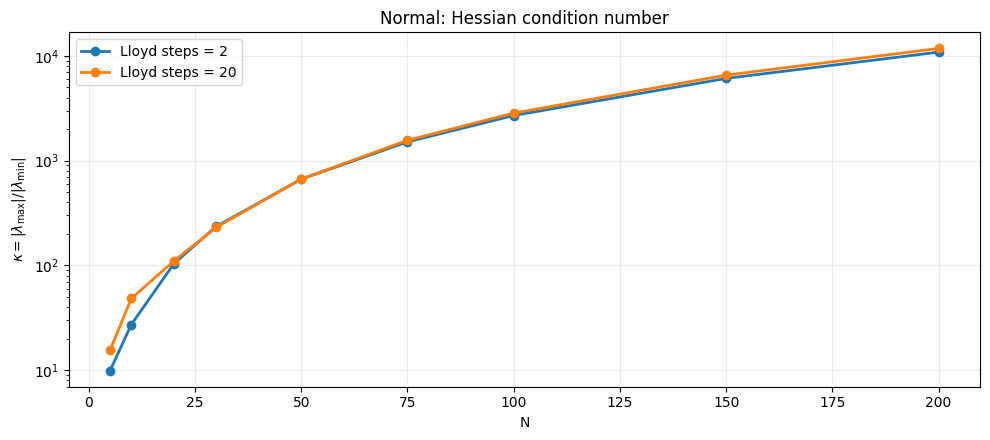

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_kappa.svg


In [4]:
# Plot 1/4: κ vs N (compare Lloyd step counts)
fig, ax = plt.subplots(figsize=(10, 4.5))

for n_lloyd in lloyd_steps_list:
    rows = rows_by_steps[int(n_lloyd)]
    Ns = np.array([r["N"] for r in rows], dtype=float)
    kappas = np.array([r["kappa"] for r in rows], dtype=float)
    ax.plot(Ns, kappas, marker="o", linewidth=2, label=f"Lloyd steps = {n_lloyd}")

ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel(r"$\kappa = |\lambda_{\max}| / |\lambda_{\min}|$")
ax.set_title("Normal: Hessian condition number")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_kappa.svg"
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

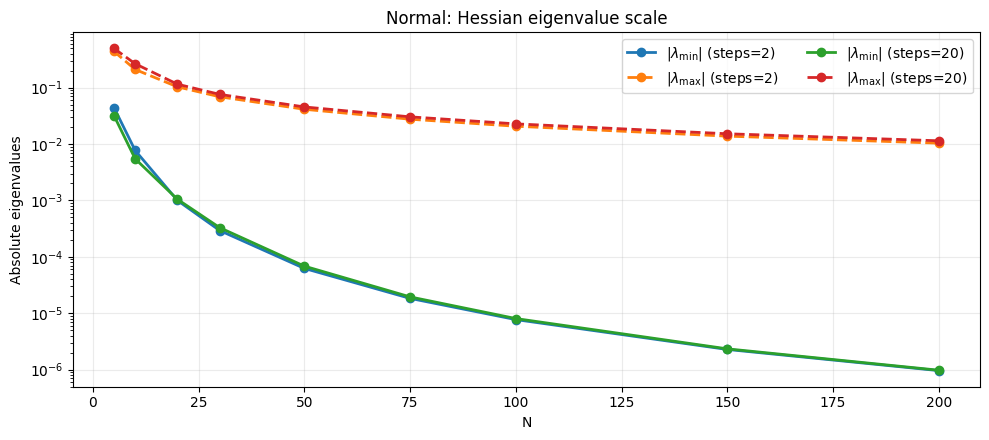

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_eigs.svg


In [5]:
# Plot 2/4: |λ_min| and |λ_max| vs N (compare Lloyd step counts)
fig, ax = plt.subplots(figsize=(10, 4.5))

for n_lloyd in lloyd_steps_list:
    rows = rows_by_steps[int(n_lloyd)]
    Ns = np.array([r["N"] for r in rows], dtype=float)
    abs_lam_min = np.array([r["abs_lambda_min"] for r in rows], dtype=float)
    abs_lam_max = np.array([r["abs_lambda_max"] for r in rows], dtype=float)

    ax.plot(Ns, abs_lam_min, marker="o", linewidth=2, label=fr"$|\lambda_{{\min}}|$ (steps={n_lloyd})")
    ax.plot(Ns, abs_lam_max, marker="o", linewidth=2, linestyle="--", label=fr"$|\lambda_{{\max}}|$ (steps={n_lloyd})")

ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel("Absolute eigenvalues")
ax.set_title("Normal: Hessian eigenvalue scale")
ax.grid(alpha=0.25)
ax.legend(loc="best", ncol=2)
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_eigs.svg"
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

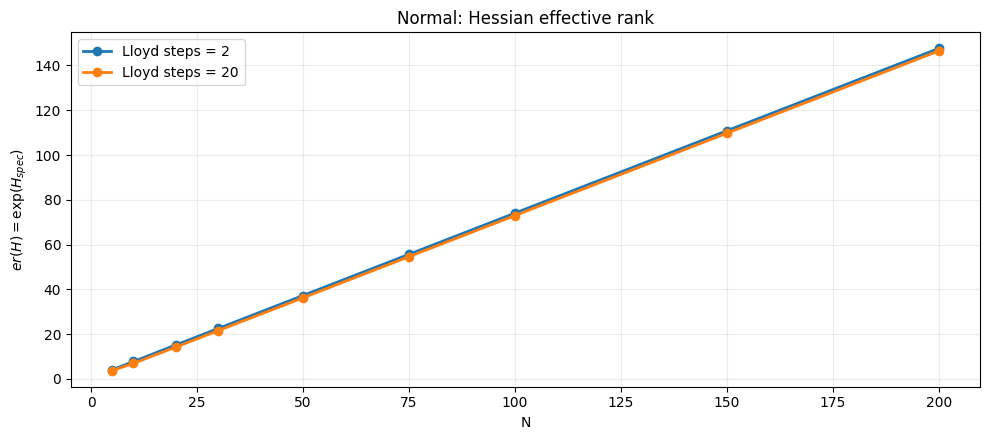

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_effective_rank.svg


In [6]:
# Plot 3/4: effective rank er(H) vs N (compare Lloyd step counts)
fig, ax = plt.subplots(figsize=(10, 4.5))

for n_lloyd in lloyd_steps_list:
    rows = rows_by_steps[int(n_lloyd)]
    Ns = np.array([r["N"] for r in rows], dtype=float)
    effective_rank = np.array([r["effective_rank"] for r in rows], dtype=float)
    ax.plot(Ns, effective_rank, marker="o", linewidth=2, label=f"Lloyd steps = {n_lloyd}")

ax.set_xlabel("N")
ax.set_ylabel(r"$er(H)=\exp(H_{spec})$")
ax.set_title("Normal: Hessian effective rank")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_effective_rank.svg"
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

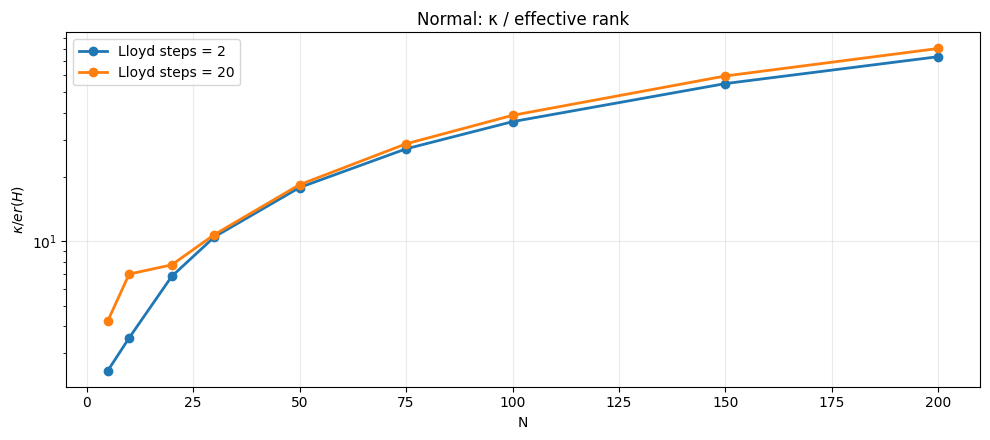

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_ratio.svg


In [7]:
# Plot 4/4: κ / er(H) vs N (compare Lloyd step counts)
fig, ax = plt.subplots(figsize=(10, 4.5))

for n_lloyd in lloyd_steps_list:
    rows = rows_by_steps[int(n_lloyd)]
    Ns = np.array([r["N"] for r in rows], dtype=float)
    kappas = np.array([r["kappa"] for r in rows], dtype=float)
    effective_rank = np.array([r["effective_rank"] for r in rows], dtype=float)

    ratio_kappa_er = np.divide(kappas, effective_rank, out=np.full_like(kappas, np.nan), where=effective_rank != 0)
    ax.plot(Ns, ratio_kappa_er, marker="o", linewidth=2, label=f"Lloyd steps = {n_lloyd}")

ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel(r"$\kappa / er(H)$")
ax.set_title("Normal: κ / effective rank")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_ratio.svg"
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

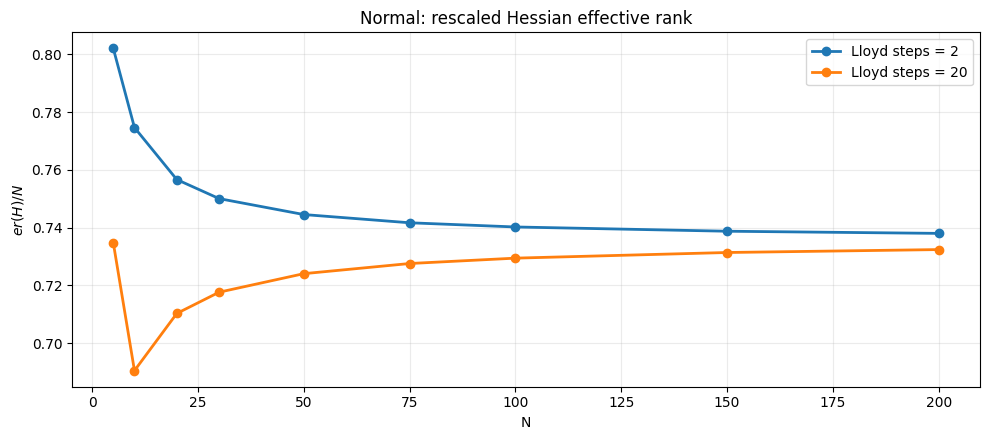

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_effective_rank_norm.svg


In [8]:
# Extra plot: rescaled effective rank er(H) / N vs N (compare Lloyd step counts)

fig, ax = plt.subplots(figsize=(10, 4.5))

for n_lloyd in lloyd_steps_list:
    rows = rows_by_steps[int(n_lloyd)]
    Ns = np.array([r["N"] for r in rows], dtype=float)
    er_norm = np.array([r["effective_rank_norm"] for r in rows], dtype=float)
    ax.plot(Ns, er_norm, marker="o", linewidth=2, label=f"Lloyd steps = {n_lloyd}")

ax.set_xlabel("N")
ax.set_ylabel(r"$er(H)/N$")
ax.set_title("Normal: rescaled Hessian effective rank")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_effective_rank_norm.svg"
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

In [9]:
# LM-style regularization study (computed at centroids after `lloyd_steps_long`)
# We analyze H_λ = H + λ I and H_λ = H + λ diag(H) for λ on `lm_lambda_grid`.

lambda_grid = np.array(lm_lambda_grid, dtype=float)
Ns = np.array(N_list, dtype=int)

# Arrays shape: (len(lambda_grid), len(Ns))
metrics_identity = {
    "kappa": np.full((len(lambda_grid), len(Ns)), np.nan, dtype=float),
    "effective_rank": np.full((len(lambda_grid), len(Ns)), np.nan, dtype=float),
    "effective_rank_norm": np.full((len(lambda_grid), len(Ns)), np.nan, dtype=float),
}
metrics_diag = {
    "kappa": np.full((len(lambda_grid), len(Ns)), np.nan, dtype=float),
    "effective_rank": np.full((len(lambda_grid), len(Ns)), np.nan, dtype=float),
    "effective_rank_norm": np.full((len(lambda_grid), len(Ns)), np.nan, dtype=float),
}

for j, N in enumerate(Ns):
    x0 = initial_centroids_quantiles(int(N))
    centroids, _, _ = quantizer.deterministic_lloyd_method(x0, nbr_iterations=int(lloyd_steps_long))

    H = quantizer.hessian_distortion(centroids)
    diagH = np.diag(np.diag(H))

    for i, lam in enumerate(lambda_grid):
        H_id = H + float(lam) * np.eye(len(centroids))
        H_dg = H + float(lam) * diagH

        for label, M, store in (
            ("identity", H_id, metrics_identity),
            ("diag", H_dg, metrics_diag),
        ):
            evals = scipy.linalg.eigvalsh(M)
            lam_min = float(evals[0])
            lam_max = float(evals[-1])
            abs_lam_min = abs(lam_min)
            abs_lam_max = abs(lam_max)
            kappa = (abs_lam_max / abs_lam_min) if (abs_lam_min != 0.0 and np.isfinite(abs_lam_min)) else float("inf")
            _, er = effective_rank_from_eigenvalues(evals)

            store["kappa"][i, j] = float(kappa)
            store["effective_rank"][i, j] = float(er)
            store["effective_rank_norm"][i, j] = float(er) / float(N)

print(
    f"Computed LM grids at Lloyd steps = {lloyd_steps_long} for N={list(Ns)} and λ={list(lambda_grid)}"
)

Computed LM grids at Lloyd steps = 20 for N=[np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(50), np.int64(75), np.int64(100), np.int64(150), np.int64(200)] and λ=[np.float64(1e-06), np.float64(1e-05), np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.1), np.float64(1.0), np.float64(10.0), np.float64(100.0)]


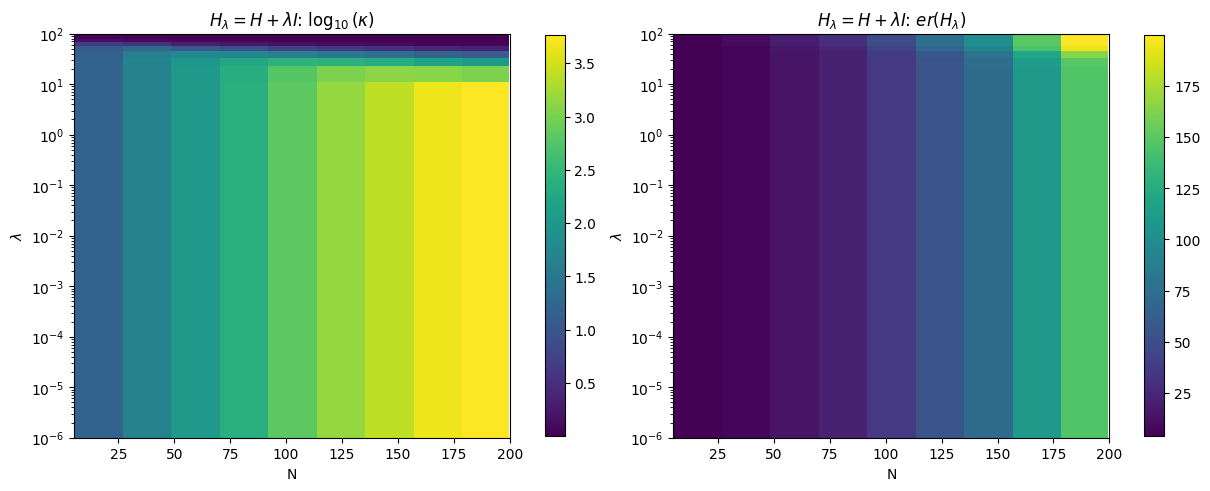

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_identity_grid.svg


In [10]:
# Grid plot: H + λ I (LM identity damping)
# y-axis shows λ values (log scale), not log10(λ).

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.8), constrained_layout=True)

# Left: log10 κ
ax = axes[0]
Z = np.log10(metrics_identity["kappa"])
im = ax.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[Ns.min(), Ns.max(), float(lambda_grid.min()), float(lambda_grid.max())],
)
ax.set_yscale("log")
ax.set_title(r"$H_\lambda = H + \lambda I$: $\log_{10}(\kappa)$")
ax.set_xlabel("N")
ax.set_ylabel(r"$\lambda$")
fig.colorbar(im, ax=ax, fraction=0.046)

# Right: effective rank
ax = axes[1]
Z2 = metrics_identity["effective_rank"]
im2 = ax.imshow(
    Z2,
    aspect="auto",
    origin="lower",
    extent=[Ns.min(), Ns.max(), float(lambda_grid.min()), float(lambda_grid.max())],
)
ax.set_yscale("log")
ax.set_title(r"$H_\lambda = H + \lambda I$: $er(H_\lambda)$")
ax.set_xlabel("N")
ax.set_ylabel(r"$\lambda$")
fig.colorbar(im2, ax=ax, fraction=0.046)

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_identity_grid.svg"
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

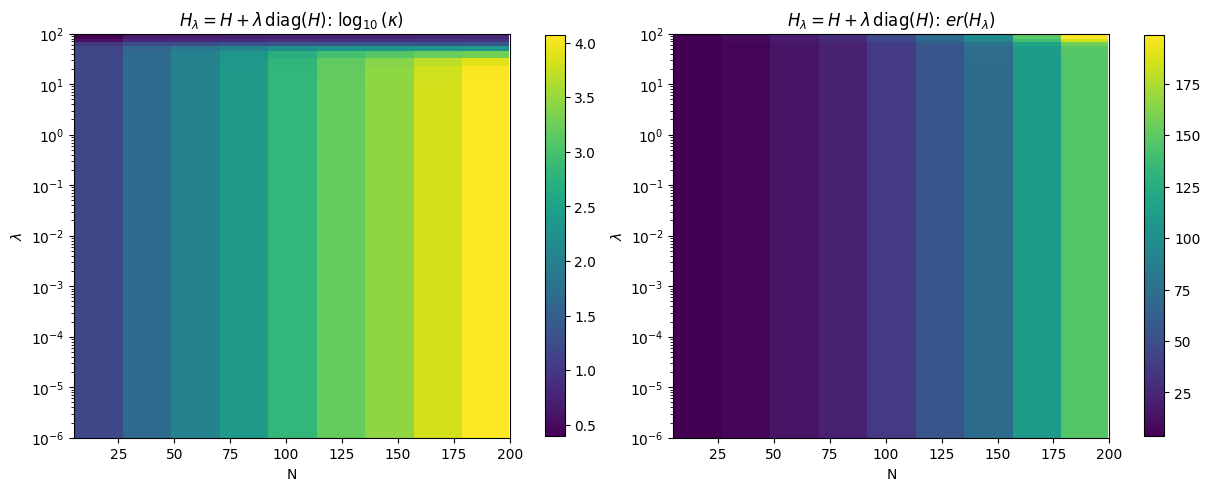

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_diag_grid.svg


In [11]:
# Grid plot: H + λ diag(H) (LM diagonal damping)
# y-axis shows λ values (log scale), not log10(λ).

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.8), constrained_layout=True)

# Left: log10 κ
ax = axes[0]
Z = np.log10(metrics_diag["kappa"])
im = ax.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[Ns.min(), Ns.max(), float(lambda_grid.min()), float(lambda_grid.max())],
)
ax.set_yscale("log")
ax.set_title(r"$H_\lambda = H + \lambda\,\mathrm{diag}(H)$: $\log_{10}(\kappa)$")
ax.set_xlabel("N")
ax.set_ylabel(r"$\lambda$")
fig.colorbar(im, ax=ax, fraction=0.046)

# Right: effective rank
ax = axes[1]
Z2 = metrics_diag["effective_rank"]
im2 = ax.imshow(
    Z2,
    aspect="auto",
    origin="lower",
    extent=[Ns.min(), Ns.max(), float(lambda_grid.min()), float(lambda_grid.max())],
)
ax.set_yscale("log")
ax.set_title(r"$H_\lambda = H + \lambda\,\mathrm{diag}(H)$: $er(H_\lambda)$")
ax.set_xlabel("N")
ax.set_ylabel(r"$\lambda$")
fig.colorbar(im2, ax=ax, fraction=0.046)

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_diag_grid.svg"
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

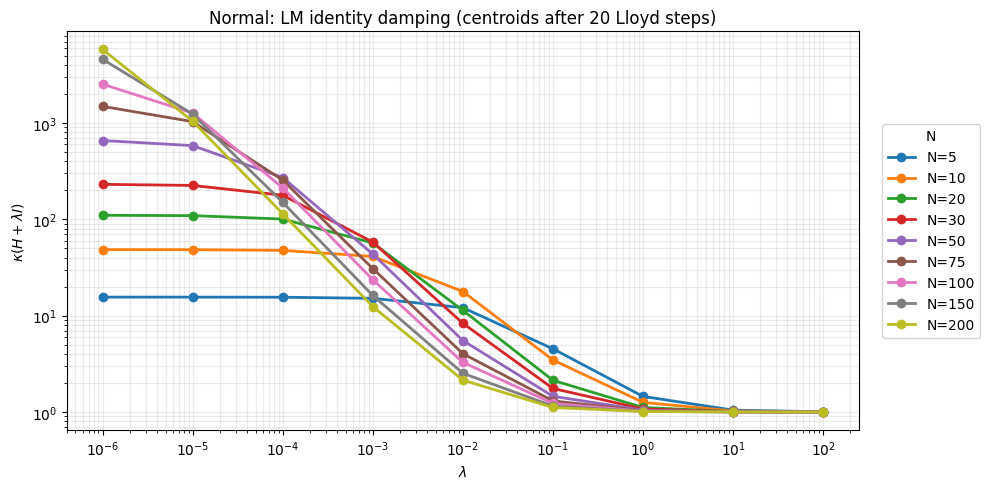

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_identity_kappa_curves.svg


In [12]:
# Curves: κ(λ) for H + λ I, one curve per N

fig, ax = plt.subplots(figsize=(10, 5))

for j, N in enumerate(Ns):
    ax.plot(lambda_grid, metrics_identity["kappa"][:, j], marker="o", linewidth=2, label=f"N={int(N)}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\kappa(H+\lambda I)$")
ax.set_title(f"Normal: LM identity damping (centroids after {lloyd_steps_long} Lloyd steps)")
ax.grid(alpha=0.25, which="both")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="N")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_identity_kappa_curves.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

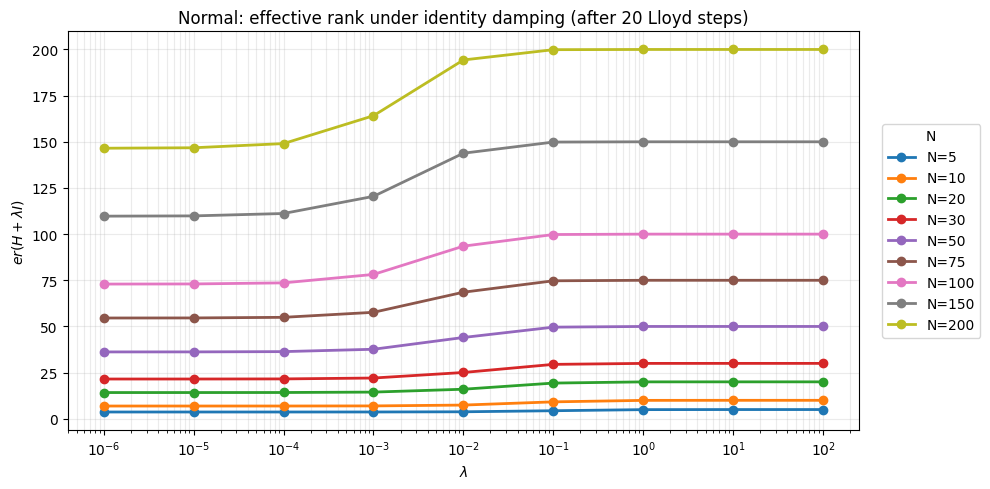

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_identity_er_curves.svg


In [13]:
# Curves: er(H_λ) for H + λ I, one curve per N

fig, ax = plt.subplots(figsize=(10, 5))

for j, N in enumerate(Ns):
    ax.plot(lambda_grid, metrics_identity["effective_rank"][:, j], marker="o", linewidth=2, label=f"N={int(N)}")

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$er(H+\lambda I)$")
ax.set_title(f"Normal: effective rank under identity damping (after {lloyd_steps_long} Lloyd steps)")
ax.grid(alpha=0.25, which="both")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="N")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_identity_er_curves.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

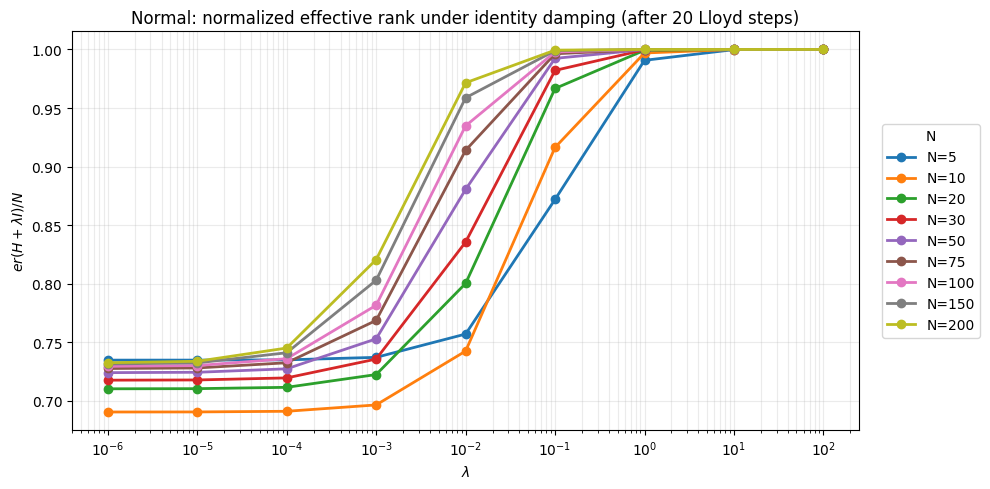

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_identity_er_norm_curves.svg


In [14]:
# Curves: er(H_λ)/N for H + λ I, one curve per N

fig, ax = plt.subplots(figsize=(10, 5))

for j, N in enumerate(Ns):
    ax.plot(lambda_grid, metrics_identity["effective_rank_norm"][:, j], marker="o", linewidth=2, label=f"N={int(N)}")

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$er(H+\lambda I)/N$")
ax.set_title(f"Normal: normalized effective rank under identity damping (after {lloyd_steps_long} Lloyd steps)")
ax.grid(alpha=0.25, which="both")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="N")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_identity_er_norm_curves.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

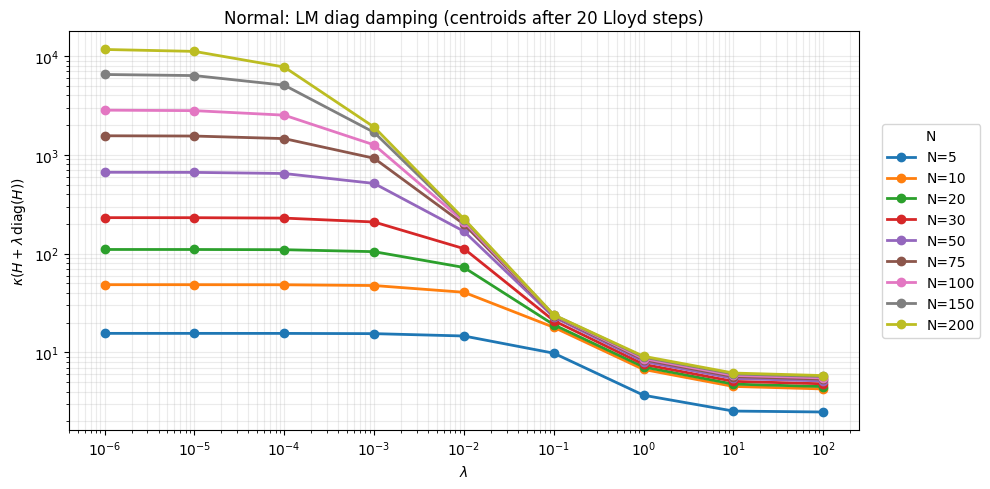

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_diag_kappa_curves.svg


In [15]:
# Curves: κ(λ) for H + λ diag(H), one curve per N

fig, ax = plt.subplots(figsize=(10, 5))

for j, N in enumerate(Ns):
    ax.plot(lambda_grid, metrics_diag["kappa"][:, j], marker="o", linewidth=2, label=f"N={int(N)}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\kappa(H+\lambda\,\mathrm{diag}(H))$")
ax.set_title(f"Normal: LM diag damping (centroids after {lloyd_steps_long} Lloyd steps)")
ax.grid(alpha=0.25, which="both")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="N")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_diag_kappa_curves.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

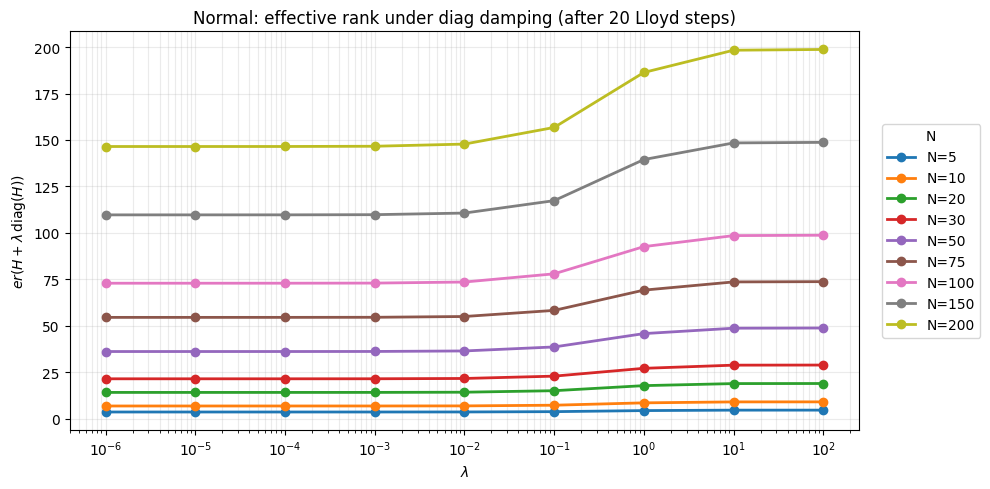

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_diag_er_curves.svg


In [16]:
# Curves: er(H_λ) for H + λ diag(H), one curve per N

fig, ax = plt.subplots(figsize=(10, 5))

for j, N in enumerate(Ns):
    ax.plot(lambda_grid, metrics_diag["effective_rank"][:, j], marker="o", linewidth=2, label=f"N={int(N)}")

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$er(H+\lambda\,\mathrm{diag}(H))$")
ax.set_title(f"Normal: effective rank under diag damping (after {lloyd_steps_long} Lloyd steps)")
ax.grid(alpha=0.25, which="both")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="N")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_diag_er_curves.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")

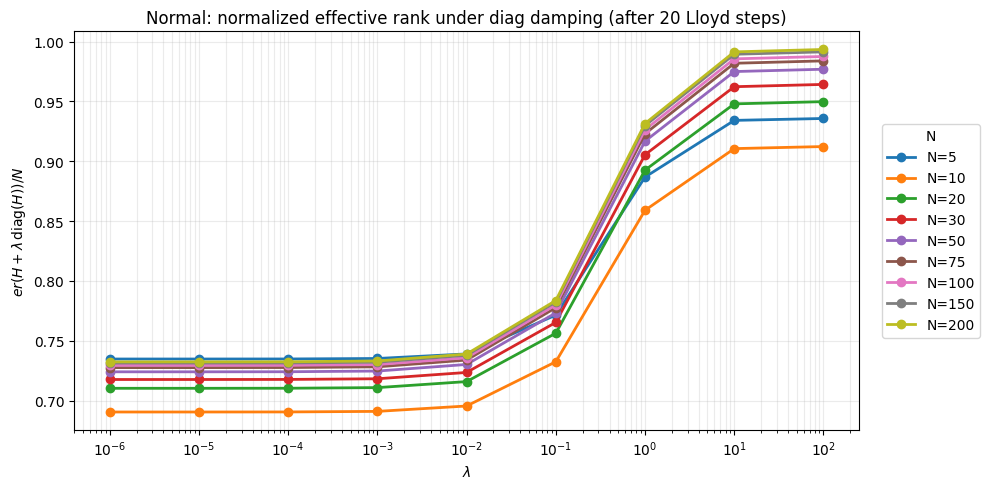

Saved SVG (matplotlib): /Users/montest/GitHub/deterministic-methods-optimal-quantization/notebooks/_svg/normal_hessian_conditioning_lm_diag_er_norm_curves.svg


In [17]:

# Curves: er(H_λ)/N for H + λ diag(H), one curve per N

fig, ax = plt.subplots(figsize=(10, 5))

for j, N in enumerate(Ns):
    ax.plot(lambda_grid, metrics_diag["effective_rank_norm"][:, j], marker="o", linewidth=2, label=f"N={int(N)}")

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$er(H+\lambda\,\mathrm{diag}(H))/N$")
ax.set_title(f"Normal: normalized effective rank under diag damping (after {lloyd_steps_long} Lloyd steps)")
ax.grid(alpha=0.25, which="both")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="N")
fig.tight_layout()

svg_dir = repo_root / "notebooks" / "_svg"
svg_dir.mkdir(parents=True, exist_ok=True)
svg_path = svg_dir / "normal_hessian_conditioning_lm_diag_er_norm_curves.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved SVG (matplotlib): {svg_path}")